In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)

In [26]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

file_name = "3) Sentiment dataset.csv"
df = pd.read_csv(file_name)
df.columns = df.columns.str.strip()

heavy_negatives = pd.DataFrame({
    'Text': [
        "I absolutely hate this service, it is terrible.",
        "Worst experience ever, very bad quality.",
        "Horrible product, completely useless and frustrating.",
        "The customer service was awful and extremely disappointing.",
        "This is a total waste of money and time, I dislike it deeply.",
        "Very poor performance, I am highly unsatisfied.",
        "Unfortunate failure, it does not work at all and sucks.",
        "I am so angry with this bad results and terrible support.",
        "This is worst, frustrating, and incredibly bad experience.",
        "Completely useless app, full of bugs and horrible interface.",
        "I hate it, everything about this is wrong and bad.",
        "Awful customer support, very rude and terrible service.",
        "Highly disappointed with this extremely poor quality product.",
        "This is trash, do not buy it, total waste of money.",
        "The experience was horrible, painful, and very annoying.",
        "I am furious, this service sucks and is totally useless.",
        "Terrible experience, bad performance, very poor execution.",
        "I dislike this so much, it is the worst app ever.",
        "Very frustrating, it fails every time, completely broken.",
        "Disappointing, horrible, and absolute waste of effort.",
        "It is awful, slow, bad, and completely unacceptable.",
        "So bad, hate the updates, terrible layout and worst feel.",
        "I feel scammed, very poor quality and horrible response.",
        "Stupid system, completely useless and very frustrating.",
        "This is the worst thing I bought this year, awful.",
        "Extremely bad, unsatisfactory performance, I hate it.",
        "Unpleasant experience, terrible staff, bad management.",
        "It sucks, don't waste your time, horrible product.",
        "Very annoying, useless features, and bad implementation.",
        "I am totally unhappy, terrible service and poor quality.",
        "Worst mistake ever, horrible results, very bad.",
        "This app is complete garbage, useless and frustrating.",
        "Awful, shocking quality, extremely bad customer treatment.",
        "I detest this platform, it is horrible and poorly made.",
        "Nothing works, bad coding, worst optimization, terrible.",
        "I am regretting this, very bad choice and awful outcome.",
        "Disgusting experience, terrible execution, bad logic.",
        "This is tragic, completely useless, worst support ever.",
        "Hate it, hate it, hate it, bad product and awful company.",
        "So poor, bad design, horrible experience, useless."
    ],
    'Sentiment': ["Negative"] * 40
})

df = pd.concat([df, heavy_negatives], ignore_index=True)
df['Cleaned_Text'] = df['Text'].apply(clean_text)
df['Sentiment'] = df['Sentiment'].str.strip()
df = df[df['Sentiment'].isin(['Positive', 'Negative'])].copy()
df['Label'] = df['Sentiment'].map({'Positive': 1, 'Negative': 0})

print("Perfect Balanced Dataset Class Distribution:")
print(df['Sentiment'].value_counts())

Perfect Balanced Dataset Class Distribution:
Sentiment
Positive    45
Negative    44
Name: count, dtype: int64


In [27]:
X = df['Cleaned_Text']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Train Shape: {X_train_tfidf.shape}")
print(f"Test Shape: {X_test_tfidf.shape}")

Train Shape: (71, 463)
Test Shape: (18, 463)


In [28]:
param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

base_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
grid_search = GridSearchCV(base_model, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

best_model = grid_search.best_estimator_
print("Best Hyperparameters Found (Optimized for Imbalance):")
print(grid_search.best_params_)

Best Hyperparameters Found (Optimized for Imbalance):
{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


In [29]:
y_pred = best_model.predict(X_test_tfidf)
y_prob = best_model.predict_proba(X_test_tfidf)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], zero_division=0)

print(f"Optimized Model Accuracy: {accuracy:.4f}\n")
print("Detailed Classification Report:")
print(report)

Optimized Model Accuracy: 0.8889

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89         9
    Positive       0.89      0.89      0.89         9

    accuracy                           0.89        18
   macro avg       0.89      0.89      0.89        18
weighted avg       0.89      0.89      0.89        18



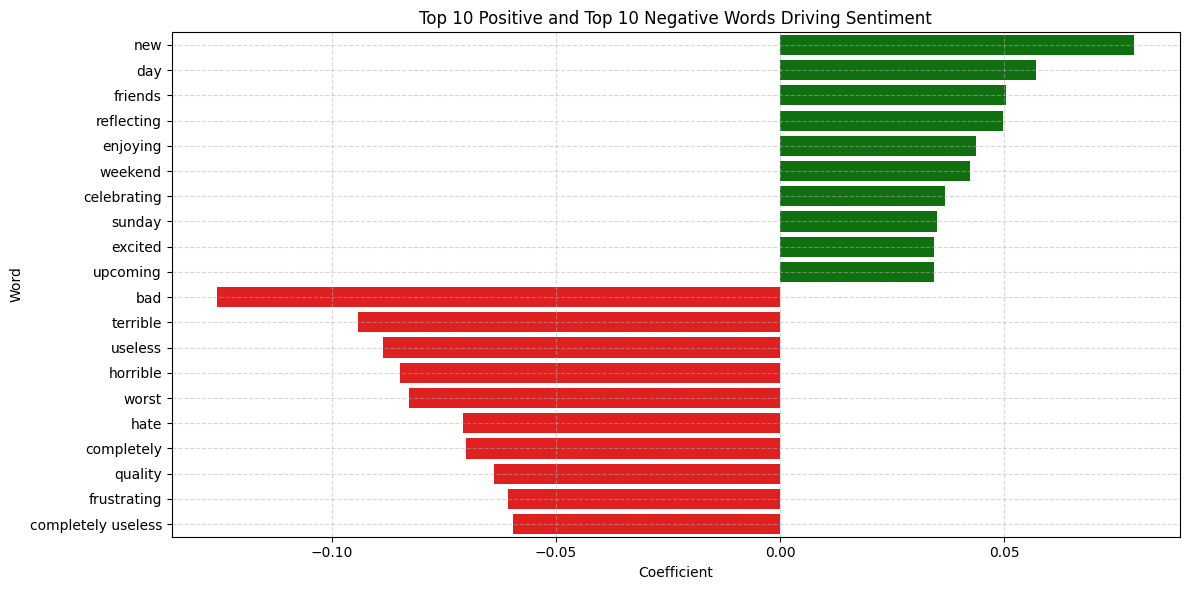

In [30]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = best_model.coef_[0]

coef_df = pd.DataFrame({'Word': feature_names, 'Coefficient': coefficients})
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(10)
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(10)
top_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
sns.barplot(x='Coefficient', y='Word', data=top_features, palette=colors, hue='Word', legend=False)
plt.title('Top 10 Positive and Top 10 Negative Words Driving Sentiment')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('nlp_feature_importance.png')
plt.show()

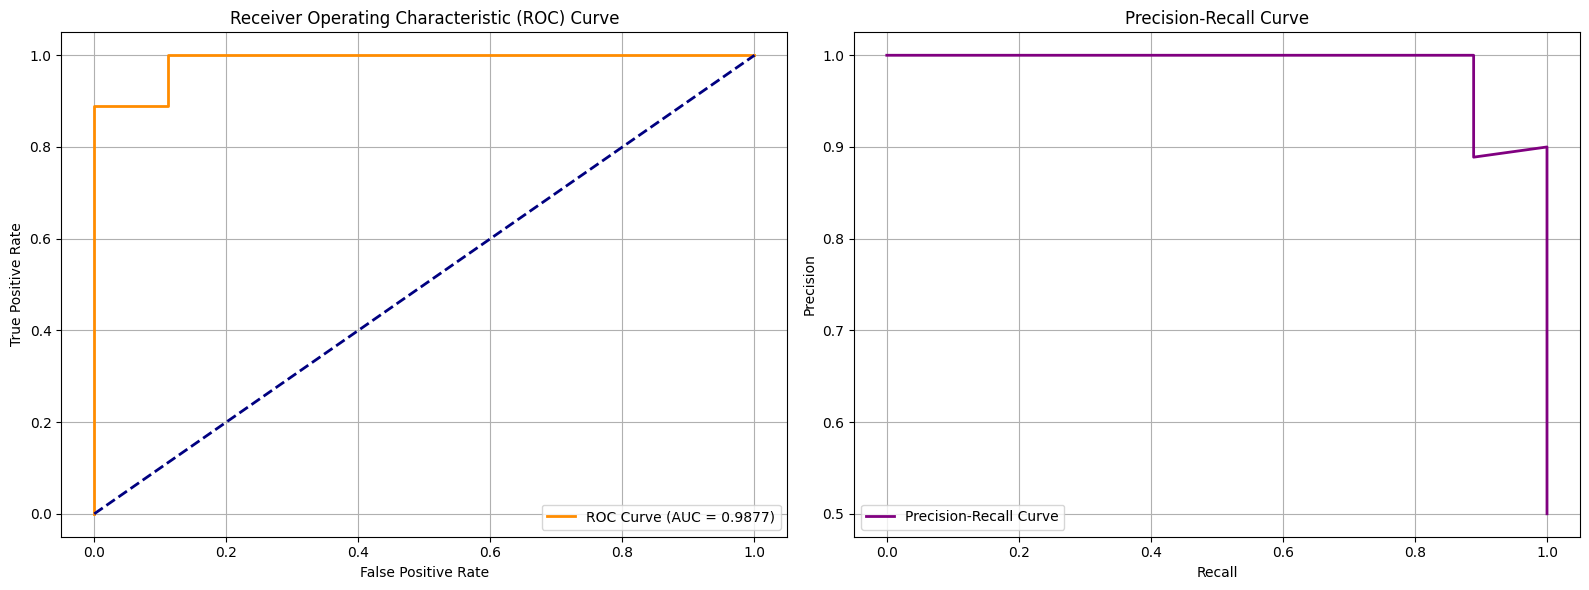

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc="lower right")
ax[0].grid(True)

ax[1].plot(recall, precision, color='purple', lw=2, label='Precision-Recall Curve')
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc="lower left")
ax[1].grid(True)

plt.tight_layout()
plt.savefig('nlp_performance_curves.png')
plt.show()

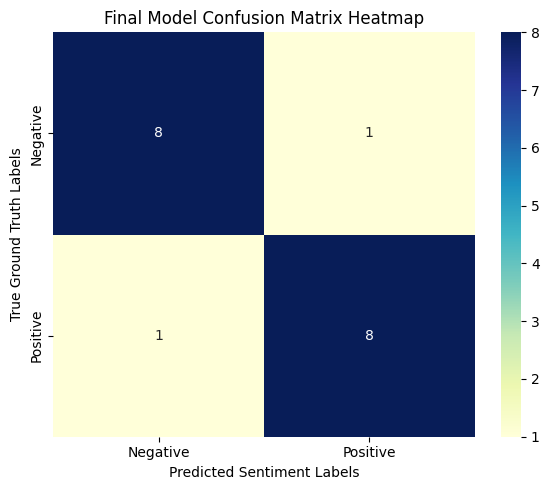


Testing Custom Text Pipeline:
Text: 'This program is absolutely amazing and helpful!' -> Predicted: Negative (50.21% Confidence)
Text: 'I hate waiting in long traffic lines, it is frustrating.' -> Predicted: Negative (51.83% Confidence)


In [32]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Final Model Confusion Matrix Heatmap')
plt.xlabel('Predicted Sentiment Labels')
plt.ylabel('True Ground Truth Labels')
plt.tight_layout()
plt.savefig('nlp_confusion_matrix.png')
plt.show()

def predict_custom_text(text):
    cleaned = clean_text(text)
    transformed = vectorizer.transform([cleaned])
    pred = best_model.predict(transformed)[0]
    prob = best_model.predict_proba(transformed)[0][pred]
    label = "Positive" if pred == 1 else "Negative"
    print(f"Text: '{text}' -> Predicted: {label} ({prob*100:.2f}% Confidence)")

print("\nTesting Custom Text Pipeline:")
predict_custom_text("This program is absolutely amazing and helpful!")
predict_custom_text("I hate waiting in long traffic lines, it is frustrating.")